In [1]:
import os, pickle, tempfile
import pandas as pd

In [2]:
import sys

sys.path.append("../../training_data")

In [3]:
from utils.utils import Cif, CifFileWriter
from utils.pocket_utils import Pocket

# Data

In [4]:
extra_set_path = "../../training_data/8.Apos/Extra_set"

In [5]:
with open(f"{extra_set_path}/pockets_features.pkl", "rb") as f:
    news = pickle.load(f)

len(news), news

(24,
 {'8sgj':    Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
  0     8sgj  pocket16   12       0.000000       0.000000     0      -0.0342   
  1     8sgj  pocket28   14       0.000000       0.000000     0      -0.1447   
  2     8sgj  pocket18   13       0.028571       0.076923     0      -0.0508   
  3     8sgj  pocket11   19       0.000000       0.000000     0       0.0417   
  4     8sgj  pocket25   13       0.000000       0.000000     0      -0.1152   
  5     8sgj  pocket15    9       0.085714       0.333333     0      -0.0332   
  6     8sgj   pocket7    8       0.000000       0.000000     0       0.1316   
  7     8sgj  pocket22   10       0.000000       0.000000     0      -0.0848   
  8     8sgj  pocket13    8       0.000000       0.000000     0       0.0031   
  9     8sgj  pocket23   40       0.000000       0.000000     0      -0.1057   
  10    8sgj  pocket14    9

In [6]:
with open(f"{extra_set_path}/apos_sites.pkl", "rb") as f:
    news_sites =  {k: [{"site": s["site"]} for s in v.values()] for k,v in pickle.load(f).items() if k in news}

len(news_sites), news_sites

(24,
 {'8sgj': [{'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            VAL             A               1          134                 ?   
    1            LEU             A               1          137                 ?   
    2            THR             A               1          138                 ?   
    3            ALA             A               1          141                 ?   
    4            HIS             A               1          200                 ?   
    5            VAL             A               1          203                 ?   
    6            PHE             A               1          204                 ?   
    7            VAL             A               1          206                 ?   
    8            THR             A               1          207                 ?   
    9            ALA             A               1          208                 ?   
    10           TRP             A          

In [7]:
with open(f"{extra_set_path}/apos.pkl", "rb") as f:
    apos = {k: {k2: v2 for k2, v2 in v.items() if k2 in news} for k, v in pickle.load(f).items()}

len(apos), apos

(24,
 {'8jp0': {'8sgj': ['A']},
  '8f4s': {'7l6r': ['A']},
  '7gqu': {'6yhr': ['A']},
  '7yg5': {'7xlq': ['A']},
  '8v81': {'5uak': ['A']},
  '6z1m': {'6z1h': ['A']},
  '9mfs': {'8szq': ['A']},
  '7f8p': {'5e1i': ['A']},
  '7p2v': {'6gx3': ['D']},
  '7qpn': {'2gk9': ['A']},
  '7u4k': {'2gs3': ['A']},
  '7v39': {'7v37': ['A']},
  '7zpe': {'9di9': ['A']},
  '8cgw': {'5c97': ['A']},
  '8crc': {'2ojx': ['A']},
  '8fpi': {'6uen': ['A']},
  '8qtk': {'3pfv': ['A']},
  '8y6w': {'8y6y': ['A']},
  '9dol': {'4n22': ['A']},
  '9ebs': {'9di2': ['B']},
  '9fsj': {'9fsk': ['A']},
  '9o2m': {'5e97': ['A']},
  '9oul': {'9ouk': ['B']},
  '9prs': {'8yf0': ['A']}})

In [8]:
assert all(len(sites) == 1 for sites in news_sites.values()), "Not all apos have a single annotated site"

In [9]:
models = pd.read_pickle("models_lenient_labelling.pkl")

models

{'model5': {'results': {'2gk9': {'pocket11': {'prob': 0.00021687464322894812,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.09090909090909091,
     'pocket_in_site': 0.09090909090909091,
     'site_in_pocket': 0.045454545454545456},
    'pocket15': {'prob': 0.00956228468567133,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.8571428571428571,
     'pocket_in_site': 0.8571428571428571,
     'site_in_pocket': 0.2727272727272727},
    'pocket7': {'prob': 0.002078430261462927,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket13': {'prob': 0.008308240212500095,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket14': {'prob': 1.7926828022041263e-08,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.1111111111111111,
     'pocket_in_site': 0.1111111111111111,
     'site_in_pocket': 0.045454545454545456},
    'pocket1': {'p

In [10]:
colors = {
    "orange": "#D55E00".lower(),
    "green": "#009E73".lower(),
    "blue": "#0072B2".lower(),
    "yellow": "#F0E442".lower()
}

# Labelling

In [11]:
# Percentage of residues of "one" in "other"
get_overlap = lambda one, other: (
    len( one.merge(other) ) / len(one)
)

def get_label(overlaps, site_in_pocket=None, pocket_in_site=None):
    assert not (site_in_pocket==None and pocket_in_site==None)
    
    if site_in_pocket is None:
        return int( overlaps["pocket_in_site"] >= pocket_in_site )
    if pocket_in_site is None:
        return int( overlaps["site_in_pocket"] >= site_in_pocket )
    return int( overlaps["site_in_pocket"] >= site_in_pocket or overlaps["pocket_in_site"] >= pocket_in_site )

In [12]:
get_overlaps = lambda pdb, pocketd: max(
    (
        {
            name: get_overlap(*one_in_other)
            for name, one_in_other in (
                ("pocket_in_site", (pocketd["residues"], site["site"])),
                ("site_in_pocket", (site["site"], pocketd["residues"])),
            )
        }
        for site in news_sites[pdb]
    ),
    key=lambda x: x["site_in_pocket"]
)


# get_overlaps_special = lambda pdb, pocketd: max(
#     (
#         {
#             name: get_overlap(*one_in_other)
#             for name, one_in_other in (
#                 ("pocket_in_site", (pocketres, site)),
#                 ("site_in_pocket", (site, pocketres)),
#             )
#         }
#         for pocketres in (pocketd["residues"],)
#             for sitei in news_sites[pdb]
#                 for site in (sitei["site"].query(f"auth_asym_id == '{pocketres.auth_asym_id.unique().item()}'"),)
#     ),
#     key=lambda x: x["site_in_pocket"]
# )
def get_overlaps_special(a,b): 
    raise Exception("This function should not be called")

In [13]:
models["model5"]["labelled"]

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
0,2gk9,pocket11,2.168746e-04,0,0,0.090909,0.090909,0.045455,7
1,2gk9,pocket15,9.562285e-03,0,0,0.857143,0.857143,0.272727,13
2,2gk9,pocket7,2.078430e-03,0,0,0.000000,0.000000,0.000000,11
3,2gk9,pocket13,8.308240e-03,0,0,0.000000,0.000000,0.000000,12
4,2gk9,pocket14,1.792683e-08,0,0,0.111111,0.111111,0.045455,1
...,...,...,...,...,...,...,...,...,...
596,9ouk,pocket5,5.975185e-04,0,0,0.190476,0.190476,0.129032,11
597,9ouk,pocket8,2.858390e-03,0,0,0.000000,0.000000,0.000000,13
598,9ouk,pocket3,3.947551e-03,0,0,0.000000,0.000000,0.000000,14
599,9ouk,pocket12,3.829194e-04,0,0,0.222222,0.222222,0.064516,10


# Scatters

## Ortho sites

In [14]:
holo_ortho_sites = pd.read_pickle("../other_tools/ortho_sites/ortho_sites.pkl")
holo_ortho_sites.keys(), holo_ortho_sites

(dict_keys(['7gqu', '8f4s', '8uk6', '8v81', '9ebs', '9mfs', '9oul', '22mj', '6s3a', '6z1m', '7p2v', '7qpn', '7zpe', '8crc', '8fpi', '21du', '8y6w', '9dol', '9prs', '7f8p', '7u4k', '7v39', '8cgw', '9o2m']),
 {'7gqu': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA             A               1           57                 ?   
   8            THR           

In [15]:
# PDBs that do not have a UniProt column for apo ortho site cross-annotation
for holo, osites in holo_ortho_sites.items():
    if holo in apos:
        for apo in (tuple(apos[holo].keys())[0],):
            for apocif in (Cif(apo, f"structures/{apo}.cif"),):
                for osite in osites:
                    if "pdbx_sifts_xref_db_acc" not in osite.columns:
                        print(holo)#[[, "pdbx_sifts_xref_db_num"]]
                

9mfs
6z1m


In [16]:
ortho_sites = {
    apo: [
        chainres
        for osite in osites
        for chain, chainres in apocif.residues.merge(
            osite[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].drop_duplicates()
        ).groupby("label_asym_id")
    ]
    for holo, osites in holo_ortho_sites.items()
    if holo in apos and holo not in ("6z1m", "9mfs")
        for apo in (tuple(apos[holo].keys())[0],)
        for apocif in (Cif(apo, f"structures/{apo}.cif"),)
}

len(ortho_sites), {k1: {k2: len(v2) for k2, v2 in enumerate(v1, 1)} for k1, v1 in ortho_sites.items()}, ortho_sites

(18,
 {'6yhr': {1: 21},
  '7l6r': {1: 30},
  '5uak': {1: 28},
  '9di2': {1: 12},
  '9ouk': {1: 14},
  '6gx3': {1: 20},
  '2gk9': {1: 18},
  '9di9': {1: 28},
  '2ojx': {1: 11},
  '6uen': {1: 17},
  '8y6y': {1: 25},
  '4n22': {1: 20},
  '8yf0': {1: 19},
  '5e1i': {1: 20},
  '2gs3': {},
  '7v37': {1: 25},
  '5c97': {1: 12},
  '5e97': {1: 19}},
 {'6yhr': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           3

<br>

For 2gs3, the 7u4k holo had an isoform UniProt ID, so the ortho site is not found with merge. However, the ortho was annotated with 2gs3 itself, so it can be extracted.

In [17]:
assert "2gs3" in ortho_sites, "This cell is not applicable anymore"
ciff = "../../training_data/8.Apos/Extra_set/origcifs/2gs3_updated.cif.gz"
cif = Cif("2gs3", ciff)
chain = ["B"]

import pymol2
with pymol2.PyMOL() as pymol:
    pymol.cmd.feedback(
        "disable", "executive", "details"
    )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
    pymol.cmd.load(ciff, "prot")

    site_atoms = pymol.cmd.get_model(f"(br. all within 6 of segi {'+'.join(chain)}) and polymer.protein")

    # Process the atom selection to obtain residue identifiers
    site_list = set(
        tuple(
            (
                a.segi, a.chain, a.resn,
                a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
            ) 
            for a in site_atoms.atom
        )
    )

    assert len(site_list) != 0, "Site selection doesn't have any residues"

    # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table
    tmp = cif.residues.merge(
        pd.DataFrame(
            site_list,
            columns=[
                "label_asym_id", "auth_asym_id", "auth_comp_id",
                "auth_seq_id", "pdbx_PDB_ins_code"
            ],
            dtype=str
        )
    )

tmp

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,ALA,A,1,58,?,70,ALA,A,1,58,UNP,P36969,70,A
1,GLN,A,1,60,?,72,GLN,A,1,60,UNP,P36969,72,Q
2,GLY,A,1,61,?,73,GLY,A,1,61,UNP,P36969,73,U
3,GLY,A,1,62,?,74,GLY,A,1,62,UNP,P36969,74,G
4,LYS,A,1,63,?,75,LYS,A,1,63,UNP,P36969,75,K
5,THR,A,1,64,?,76,THR,A,1,64,UNP,P36969,76,T
6,ASN,A,1,67,?,79,ASN,A,1,67,UNP,P36969,79,N
7,GLN,A,1,96,?,108,GLN,A,1,96,UNP,P36969,108,Q
8,TRP,A,1,151,?,163,TRP,A,1,151,UNP,P36969,163,W
9,ASN,A,1,152,?,164,ASN,A,1,152,UNP,P36969,164,N


In [18]:
assert len(tmp), "This cell is not applicable anymore"
ortho_sites["2gs3"] = [tmp,]

<br>

For 6z1m and 9mfs the label_asym_id and label_seq_id coincide with their apos.

In [19]:
ortho_sites.update({
    apo: [
        chainres
        for osite in osites
        for chain, chainres in apocif.residues.merge(
            osite[["label_asym_id", "label_seq_id"]].drop_duplicates()
        ).groupby("label_asym_id")
    ]
    for holo, osites in holo_ortho_sites.items()
    if holo in apos and holo in ("6z1m", "9mfs")
        for apo in (tuple(apos[holo].keys())[0],)
        for apocif in (Cif(apo, f"structures/{apo}.cif"),)
})

len(ortho_sites), {k1: {k2: len(v2) for k2, v2 in enumerate(v1, 1)} for k1, v1 in ortho_sites.items()}, ortho_sites

(20,
 {'6yhr': {1: 21},
  '7l6r': {1: 30},
  '5uak': {1: 28},
  '9di2': {1: 12},
  '9ouk': {1: 14},
  '6gx3': {1: 20},
  '2gk9': {1: 18},
  '9di9': {1: 28},
  '2ojx': {1: 11},
  '6uen': {1: 17},
  '8y6y': {1: 25},
  '4n22': {1: 20},
  '8yf0': {1: 19},
  '5e1i': {1: 20},
  '2gs3': {1: 11},
  '7v37': {1: 25},
  '5c97': {1: 12},
  '5e97': {1: 19},
  '8szq': {1: 27},
  '6z1h': {1: 26}},
 {'6yhr': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GL

In [20]:
ortho_labels = {}

for pdb, pdbd in models["model5"]["labelled"].groupby("pdb"):#.items():
    if pdb not in ortho_sites: continue
        
    ortho_sites_pdb = ortho_sites[pdb]
    ortho_labels[pdb] = {}
    
    for pocket, pocketd in pdbd.groupby("pocket"):#.items():
        pocketres = Pocket(f"../../training_data/8.Apos/Extra_set/pockets/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif").residues

        overlaps = max(
            (
                {
                    name: get_overlap(*one_in_other)
                        for name, one_in_other in (
                            ("pocket_in_site", (pocketres, site)),
                            ("site_in_pocket", (site, pocketres)),
                        )
                }
                for site in ortho_sites_pdb # will probably be only 1 site so only 1 value for the max()
            ),
            key=lambda x: x["site_in_pocket"]
        )
        
        ortho_labels[pdb][pocket] = {
            "ortho_label": get_label(overlaps, site_in_pocket=0.65, pocket_in_site=None),
            "ortho_max_overlap": max(overlaps.values()),
            **{f"ortho_{k}": v for k, v in overlaps.items()},
            **pocketd.squeeze().to_dict()
        }

ortho_labels.keys(), ortho_labels

(dict_keys(['2gk9', '2gs3', '2ojx', '4n22', '5c97', '5e1i', '5e97', '5uak', '6gx3', '6uen', '6yhr', '6z1h', '7l6r', '7v37', '8szq', '8y6y', '8yf0', '9di2', '9di9', '9ouk']),
 {'2gk9': {'pocket1': {'ortho_label': 1,
    'ortho_max_overlap': 0.8888888888888888,
    'ortho_pocket_in_site': 0.5161290322580645,
    'ortho_site_in_pocket': 0.8888888888888888,
    'pdb': '2gk9',
    'pocket': 'pocket1',
    'prob': 0.6127462983131409,
    'pred': 1,
    'label': 1,
    'max_overlap': 0.4090909090909091,
    'pocket_in_site': 0.2903225806451613,
    'site_in_pocket': 0.4090909090909091,
    'rank': 15},
   'pocket10': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'pdb': '2gk9',
    'pocket': 'pocket10',
    'prob': 6.376793317031115e-05,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0,
    'rank': 5},
   'pocket11': {'ortho_label': 0,
    'ortho_max_overlap': 0.2

In [21]:
pd.DataFrame((
    {
        "pdb": pdb,
        "pocket": pocket,
        **pocketd
    }
    for pdb, pockets in ortho_labels.items()
    for pocket, pocketd in pockets.items()
)).sort_values("ortho_max_overlap", ascending=False).iloc[:40]

,pdb,pocket,ortho_label,ortho_max_overlap,ortho_pocket_in_site,ortho_site_in_pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
83,5c97,pocket4,1,1.000000,0.400000,1.000000,3.909348e-01,1,1,0.333333,0.200000,0.333333,44
399,8yf0,pocket1,1,0.947368,0.197802,0.947368,8.706758e-01,1,1,0.757576,0.274725,0.757576,32
211,6uen,pocket1,1,0.941176,0.107383,0.941176,9.883447e-01,1,0,0.000000,0.000000,0.000000,83
449,9di9,pocket2,0,0.928571,0.928571,0.464286,1.719886e-02,0,0,0.071429,0.071429,0.071429,6
202,6gx3,pocket2,1,0.900000,0.900000,0.900000,5.974945e-01,1,0,0.000000,0.000000,0.000000,20
385,8szq,pocket8,1,0.888889,0.400000,0.888889,7.644089e-01,0,0,0.000000,0.000000,0.000000,33
0,2gk9,pocket1,1,0.888889,0.516129,0.888889,6.127463e-01,1,1,0.409091,0.290323,0.409091,15
19,2gs3,pocket5,0,0.875000,0.875000,0.636364,2.063152e-04,0,0,0.000000,0.000000,0.000000,1
294,6yhr,pocket1,1,0.857143,0.243243,0.857143,5.121500e-01,1,1,0.379310,0.148649,0.379310,20
447,9di2,pocket9,1,0.833333,0.666667,0.833333,1.536202e-03,0,0,0.066667,0.066667,0.035714,10


In [22]:
ortho_pockets = {
    "6z1h": ("pocket1",),
    '5e1i': ("pocket1",),
    "6yhr": ("pocket1",),
    "6gx3": ("pocket2",),
    "2gk9": ("pocket1",),
    '2gs3': ("pocket5",),
    '7v37': ("pocket5",),
    # 7xlq | 7yg5
    "9di9": ("pocket2",), # also "pocket9",),
    '5c97': ("pocket4",),
    "2ojx": ("pocket5",),
    "7l6r": ("pocket3",),
    "6uen": ("pocket1",),
    # 8sgj | 8jp0
    # 3pfv (prev. 8vw5)
    "5uak": ("pocket5",),#, "pocket39", "pocket4", "pocket54",),
    "8y6y": ("pocket8",),
    "4n22": ("pocket3",),
    "9di2": ("pocket9",),
    # 9fsk | 9fsj
    "8szq": ("pocket8",),
    # '5e97': # no good active pocket
    "9ouk": ("pocket14",),
    "8yf0": ("pocket1",),
}

ortho_pocketsf = "ortho_pockets.pkl"
pd.to_pickle(ortho_pockets, ortho_pocketsf)

ortho_pockets

{'6z1h': ('pocket1',),
 '5e1i': ('pocket1',),
 '6yhr': ('pocket1',),
 '6gx3': ('pocket2',),
 '2gk9': ('pocket1',),
 '2gs3': ('pocket5',),
 '7v37': ('pocket5',),
 '9di9': ('pocket2',),
 '5c97': ('pocket4',),
 '2ojx': ('pocket5',),
 '7l6r': ('pocket3',),
 '6uen': ('pocket1',),
 '5uak': ('pocket5',),
 '8y6y': ('pocket8',),
 '4n22': ('pocket3',),
 '9di2': ('pocket9',),
 '8szq': ('pocket8',),
 '9ouk': ('pocket14',),
 '8yf0': ('pocket1',)}

## Plots

In [23]:
df = models["model5"]["labelled"]

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

scatter_config = {
    "figsize": (1.75, 2.25),
    "point_size": 50,
    "jitter_width": 0.2,
    "grey_alpha": 0.4,
    "axis_linewidth": 0.8,
    "tick_fontsize": 12,
    "label_fontsize": 15,
    "xlabel_fontsize": 12,
    "score_title_fontsize": 13,
    "score_title_y": 1.12,
    "annotation_x_offset": 0.4,
    "yticks": [0.0, 0.25, 0.5, 0.75, 1.0],
    "ylabel_right_spine_position": 0.8125,
    "special_nbins": {"9di9": 1},
    "blue_x_shift_by_pdb": {"9di9": -0.125},
    "light_grey": "0.75",
    "xlabel_color": "0.35",
    "output_prefix": "images/boxplot_",
}

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"
rcParams["axes.linewidth"] = scatter_config["axis_linewidth"]


def get_scatter_point_color(row, light_grey=None):
    light_grey = light_grey or scatter_config["light_grey"]
    if row["pdb"] in ortho_pockets and row["pdb"] not in ("6yhr", "2gk9", "8yf0", "5c97"):
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return colors["yellow"]
    if row["pred"] and row["label"]:
        return colors["green"]
    if row["label"]:
        return colors["orange"]
    if row["pred"]:
        return colors["blue"]
    return light_grey


def get_beeswarm_offsets(probs, pdb_id, jitter_width, special_nbins=None):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0 or np.nanmax(probs) == np.nanmin(probs):
        return np.zeros_like(probs)

    nbins = (special_nbins or {}).get(pdb_id, 50)
    rng = np.random.default_rng(0)
    quant = np.round(
        nbins * (probs - np.nanmin(probs)) / (np.nanmax(probs) - np.nanmin(probs) + 1e-8)
    )
    order = np.argsort(quant + rng.normal(0, 1e-6, len(probs)))

    x_vals = np.zeros(len(probs))
    layer = 0
    last_bin = None

    for idx in order:
        if quant[idx] != last_bin:
            layer = 0
            last_bin = quant[idx]

        if layer == 0:
            offset = 0
        else:
            offset = (layer + 1) // 2
            if layer % 2 == 0:
                offset = -offset

        x_vals[idx] = offset
        layer += 1

    max_abs = np.max(np.abs(x_vals))
    if max_abs > 0:
        x_vals = x_vals / max_abs * jitter_width
    return x_vals


def plot_scatter_panel(pdb_id, df, ax=None, config=None, show_xlabel=True, show_score_title=True, save_path=None):
    config = {**scatter_config, **(config or {})}
    sub = df.query("pdb == @pdb_id").copy()
    probs = sub["prob"].to_numpy(dtype=float)
    if len(probs) == 0 or np.all(np.isnan(probs)):
        raise ValueError(f"No valid probabilities found for {pdb_id}")

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=config["figsize"])
    else:
        fig = ax.figure

    rcParams["font.size"] = config["label_fontsize"]
    rcParams["ytick.labelsize"] = config["tick_fontsize"]

    sc_colors = np.array([get_scatter_point_color(row) for _, row in sub.iterrows()], dtype=object)
    alphas = np.array([
        config["grey_alpha"] if color == config["light_grey"] else 1
        for color in sc_colors
    ])
    x_vals = get_beeswarm_offsets(
        probs,
        pdb_id=pdb_id,
        jitter_width=config["jitter_width"],
        special_nbins=config["special_nbins"],
    )

    grey_mask = sc_colors == config["light_grey"]
    blue_mask = sc_colors == colors["blue"]
    color_mask = ~(grey_mask | blue_mask)

    ax.scatter(
        x_vals[grey_mask],
        probs[grey_mask],
        s=config["point_size"],
        c=sc_colors[grey_mask],
        alpha=alphas[grey_mask],
        edgecolors="none",
        zorder=1,
        clip_on=False,
    )

    if np.any(color_mask):
        ax.scatter(
            x_vals[color_mask],
            probs[color_mask],
            s=config["point_size"],
            c=sc_colors[color_mask],
            alpha=alphas[color_mask],
            edgecolors="none",
            zorder=2,
            clip_on=False,
        )

    blue_shift = config["blue_x_shift_by_pdb"].get(pdb_id, 0.0)
    if np.any(blue_mask):
        ax.scatter(
            x_vals[blue_mask] + blue_shift,
            probs[blue_mask],
            s=config["point_size"],
            c=sc_colors[blue_mask],
            alpha=alphas[blue_mask],
            edgecolors="none",
            zorder=3,
            clip_on=False,
        )

    idx_max = int(np.nanargmax(probs))
    text_val = f"{probs[idx_max]:.3f}".rstrip("0").rstrip(".")
    ax.text(
        x_vals[idx_max] - config["jitter_width"] * config["annotation_x_offset"] + blue_shift,
        probs[idx_max],
        text_val,
        ha="right",
        va="center",
        fontsize=config["label_fontsize"],
    )

    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, 1)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(config["axis_linewidth"])
    ax.spines["right"].set_position(("axes", config["ylabel_right_spine_position"]))

    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    if config["yticks"] is None:
        ax.yaxis.set_major_locator(MaxNLocator(5))
    else:
        ax.set_yticks(config["yticks"])
        ax.set_yticklabels(["0", "", "0.5", "", "1"])
    ax.tick_params(axis="y", labelsize=config["tick_fontsize"])
    ax.set_ylabel("")
    if show_score_title:
        ax.text(
            0,
            config["score_title_y"],
            "AlloPockets\nscore",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            multialignment="center",
            fontsize=config["score_title_fontsize"],
        )
    ax.set_xlabel(f"(n = {len(sub)})" if show_xlabel else "", fontsize=config["xlabel_fontsize"], color=config["xlabel_color"])
    if show_xlabel:
        ax.xaxis.set_label_coords(0.52, -0.075)

    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=300, transparent=True)
        plt.show()
        return fig, ax

    return ax


2gk9


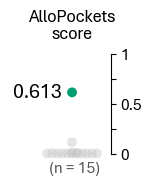

2gs3


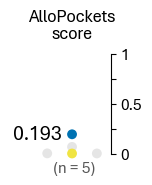

2ojx


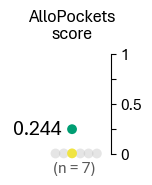

3pfv


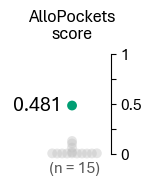

4n22


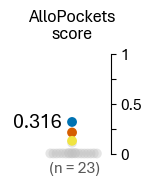

5c97


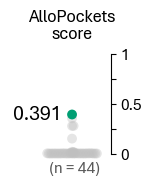

5e1i


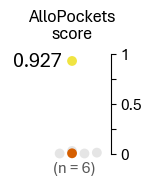

5e97


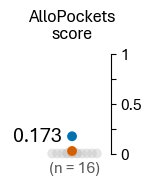

5uak


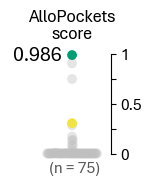

6gx3


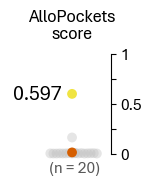

6uen


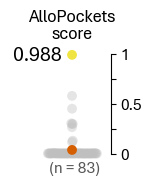

6yhr


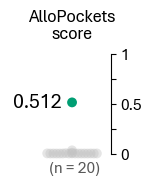

6z1h


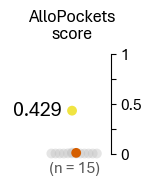

7l6r


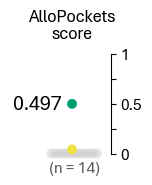

7v37


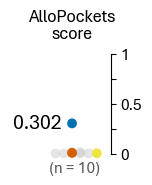

7xlq


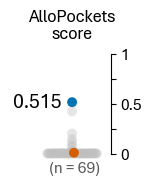

8sgj


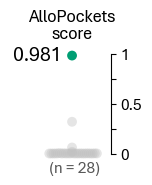

8szq


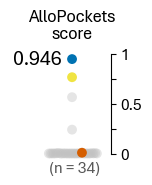

8y6y


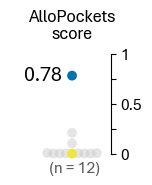

8yf0


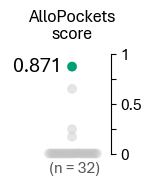

9di2


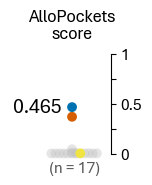

9di9


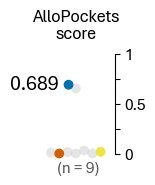

9fsk


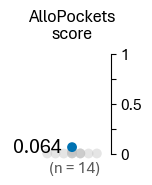

9ouk


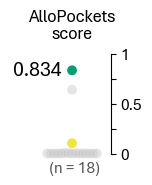

In [25]:
os.makedirs("images", exist_ok=True)

for pdb_id in df["pdb"].drop_duplicates():
    print(pdb_id)
    plot_scatter_panel(
        pdb_id,
        df,
        # save_path=f"{scatter_config['output_prefix']}{pdb_id}.svg",
    )


# Pocket functions

In [26]:
from biotite.structure.io.pdb import PDBFile

def get_pdb_atoms(f):
    atom_array = PDBFile.read(f).get_structure()
    return pd.DataFrame({
            "auth_asym_id": atom_array.chain_id,
            "auth_seq_id": atom_array.res_id,
            "auth_comp_id": atom_array.res_name,
            "auth_atom_id": atom_array.atom_name,
            "type_symbol": atom_array.element,
            "Cartn_x": atom_array.coord[0][:, 0],
            "Cartn_y": atom_array.coord[0][:, 1],
            "Cartn_z": atom_array.coord[0][:, 2],
            "pdbx_PDB_ins_code": (ic or '?' for ic in atom_array.ins_code)
        }, dtype=str)

In [27]:
def get_pocket(pocket_atoms, res_id, color):
    pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketn": res_id,
        "atoms": pocket_atoms, 
        "representation": {
            "selection": [{'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(res_id)}], 
            'color': colors[color]
        }
    }

In [28]:
def get_our_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     Cif(pdb, f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif", name=f"{pdb}_out")
    #     .atoms
    #     .query(f"label_comp_id == 'STP' and label_seq_id == '{pocketn}'")
    # )

    return {
        "pocketsf": f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif",
        "pocketn": pocketn,
        "pocket_sel": [{"label_comp_id": 'STP', "label_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)
# {
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": {'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(pocketn)}, 
#             'color': colors[color]
#         }
#     }

models["model5"]["pocketf"] = get_our_pocket

In [29]:
def get_allositepro_pocket(pdb, pocket, color):
    resultsf = next(f for f in os.listdir(f"AllositePro/{pdb}") if f.endswith("_download"))
    # pockets are 0-indexed but residue numbers start at 1
    # also pocket0 can be residue ID 2, so all pockets auth_seq_id will be sorted and then the relevant residue id taken with the 0-index pocket number
    pockets_atoms = (
        get_pdb_atoms(f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb")
        .query(f"auth_comp_id == 'STP'")
    )
    pocketn = sorted(pockets_atoms.auth_seq_id.unique())[ int(pocket.replace('pocket', '')) ]
    # pocket_atoms = pockets_atoms.query(f"auth_seq_id == '{pocketn}'")
    
    return {
        "pocketsf": f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["allositepro"]["pocketf"] = get_allositepro_pocket

In [30]:
from functools import partial

In [31]:
def get_passer_pocket(pdb, pocket, color, model):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     get_pdb_atoms(f"PASSer/{model}/{pdb}/{pdb}_out.pdb")
    #     .query(f"auth_comp_id == 'STP' and auth_seq_id == '{pocketn}'")
    # )
    
    return {
        "pocketsf": f"PASSer/{model}/{pdb}/{pdb}_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["passer_ensemble"]["pocketf"] = partial(get_passer_pocket, model="ensemble")
models["passer_automl"]["pocketf"] = partial(get_passer_pocket, model="automl")
models["passer_rank"]["pocketf"] = partial(get_passer_pocket, model="rank")

In [32]:
def get_allo_pocket(pdb, pocket, color):
    if "AF" not in pdb:
        resultsf = next(f for f in os.listdir(f"ALLO/{pdb}") if f.startswith(f"{pdb}pdb") and f.endswith("_desc.txt")).replace("_desc.txt", "")
    else:
        afpdb = pdb.lower().replace("-", "")
        resultsf = next(f for f in os.listdir(f"ALLO/{pdb}") if f.startswith(f"{afpdb}pdb") and f.endswith("_desc.txt")).replace("_desc.txt", "")
    pocket_atoms = (
        get_pdb_atoms(f"ALLO/{pdb}/pockets/{resultsf}_{pocket}_res.pdb")
    )
    
    # pocket_atoms["auth_asym_id"] = 'ZZZ'
    # pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketsf": f"ALLO/{pdb}/pockets/{resultsf}_{pocket}_res.pdb",
        "pocketn": pocket,
        "pocket_sel": [
            {"auth_asym_id": atom['auth_asym_id'], "auth_seq_id": int(atom['auth_seq_id']), "auth_atom_id": atom['auth_atom_id']}
            for i, atom in pocket_atoms.query("auth_atom_id not in ['CA', 'C', 'O', 'N', 'CB']").iterrows()
        ],
        "color": colors[color]
    }
    #{
    #     "pocketn": pocket,
    #     "atoms": pocket_atoms.query("auth_atom_id not in ['CA', 'C', 'O', 'N', 'CB']"), 
    #     "representation": {
    #         "selection": [
    #             {"auth_asym_id": "ZZZ", 'auth_seq_id': int(res)}
    #             for res in pocket_atoms["auth_seq_id"].unique()
    #         ],
    #         'color': colors[color]
    #     }
    # }

models["allo"]["pocketf"] = get_allo_pocket

In [33]:
def get_alloses_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    
    return {
        "pocketsf": f"AllosES/{pdb.upper()}/{pdb.upper()}_out/{pdb.upper()}_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["alloses"]["pocketf"] = get_alloses_pocket

In [34]:
def get_mefallosite_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    
    return {
        "pocketsf": f"MEF-AlloSite/MEF-AlloSite/data/test/{pdb.upper()}_cleaned_out/{pdb.upper()}_cleaned_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["mefallosite"]["pocketf"] = get_mefallosite_pocket

# View functions

In [35]:
import molviewspec as mvs
import json
from pathlib import Path

In [36]:
import numpy as np

In [37]:
# ass_fields_list = ["_pdbx_struct_assembly", "_pdbx_struct_assembly_gen", "_pdbx_struct_oper_list"]

def view_pockets(pdb, model, pockets:list):
    cif = Cif(pdb, f"{extra_set_path}/origcifs/{pdb}_updated.cif.gz")
    
    site = news_sites[pdb][0]
    # if pdb == "8sgj":
    #     site["site"] = site["site"].loc[lambda x: x["label_seq_id"].astype(int) < 800]
    # elif pdb == "7sns" and model == "mefallosite":
    #     site = news_sites[pdb][1]
    
    builder = mvs.create_builder()
    transformation = custom_vizs[pdb]["camera"].get("transformation", None)
    if transformation is not None:
        transformation = transformation.get(model, transformation["transformation"])
        if len(transformation) == 2:
            rot, trans = transformation
        else:
            M = np.array(transformation).reshape(4,4,order="F")
            rot, trans = M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
            .transform(rotation=rot, translation=trans)
        )
    else:
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
        )

    assets = {f'{pdb}.cif': cif.cif.text.encode()}


    if custom_vizs[pdb]["camera"]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"]["camera"].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )
    if model in custom_vizs[pdb]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"][model].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )

    # Protein and site
    for auth_asym_id, siteres in site["site"].groupby("auth_asym_id"):
        protein = (
            structure
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in custom_vizs[pdb]["selections"].get(f"protein_{auth_asym_id}", [{"auth_asym_id": auth_asym_id},])
            ])
            .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
            .color(color='#DADADA')
        )
        annos = f'annos_chain_{auth_asym_id}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'black' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in siteres.iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')

        # if model == "model5":
        for i, osite in enumerate(ortho_sites.get(pdb, [])):
            osite = osite.query(f"auth_asym_id == '{auth_asym_id}'").merge(
                siteres,
                how="left", indicator=True
            ).query("_merge == 'left_only'").drop(columns="_merge")
            
            if len(osite) == 0: continue
            annos = f'ortho_annos_{auth_asym_id}_{i}.json'
            assets[annos] = json.dumps(
                [
                    {
                        'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                        'color': colors["yellow"] # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                    }
                    for i, r in osite.iterrows()
                ]
            ).encode()
            protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
                
            
    # Ligands
    if not custom_vizs[pdb]["ligands"]["none"]:
        for entity_id in pd.DataFrame(cif.cif.data["_entity"], dtype=str).query("type == 'non-polymer'").id.unique():
            # if entity_id not in site["mod"].label_entity_id.unique():
            (
                structure
                .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
                .representation(type="ball_and_stick", custom={"molstar_representation_params": {"ignoreLight": True}})
                .color(color="white")
            )

    ligs = []
    if "model5" in custom_vizs[pdb]["ligands"]:
        ligs += custom_vizs[pdb]["ligands"]["model5"]
    if model in custom_vizs[pdb]["ligands"]:
        ligs += [ml for ml in custom_vizs[pdb]["ligands"][model] if all(ml != l for l in ligs)]
    for lig in ligs:
        (
            structure
            .component(selector=mvs.ComponentExpression(**lig))
            .representation(
                type="ball_and_stick", 
                size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(
                custom={
                    "molstar_color_theme_name": "element-symbol",
                    "molstar_color_theme_params": {
                        "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
                    }
                }
            )
            # .opacity(opacity=0.9)
        )

    # Pockets
    pockets_strs = {}
    for i, pocket in enumerate(pockets):
        pocketf = Path(pocket["pocketsf"])
        name = pocketf.name
        if name not in assets:
            # if "transformation" in custom_vizs[pdb]["camera"]:
            if transformation is not None:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                    .transform(rotation=rot, translation=trans)
                )
            else:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                )
            with open(pocketf, "r") as f:
                assets[name] = f.read().encode()
        
        (
            pockets_strs[name]
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in pocket["pocket_sel"]
            ])
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color=pocket["color"])
            .opacity(
                opacity=(
                    custom_vizs[pdb]["pocket_opacity"]
                    .get(model, {pocket["pocketn"]: 0.5})
                    .get(pocket["pocketn"])
                )
            )
        )
    


    # View
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )
    # v = mvsx.molstar_notebook(width= 1725, height= 875)
    # return v

In [38]:
def view_top(pdb, model, top=None):
    pocketf = models[model]["pocketf"]
    prob_key = models[model]["prob_key"]
    results = models[model]["results"][pdb]
    labelled = models[model]["labelled"].query(f"pdb == '{pdb}'").sort_values("prob", ascending=False)
    pos_pockets = labelled[labelled["label"] == 1]

    if top is None:
        top = labelled["label"].sum() or 1
    top_pockets = tuple(pocket for i, pocket in tuple(labelled.iterrows())[:top])

    for pocket in top_pockets:
        print(pocket["pocket"], {k: v for k, v in results[pocket["pocket"]].items() if k != "residues"}, "label:", pocket["label"])
        
    return view_pockets(
        pdb,
        model,
        tuple(
            [
                pocketf(
                    pdb, 
                    pocket["pocket"], 
                    (
                        "green" if pocket["label"] == 1 
                        else (
                            "yellow" if model == "model5" and pocket["pocket"] in ortho_pockets.get(pdb, ())
                            else "blue"
                        )
                    )
                )
                for pocket in top_pockets
            ] + [
                pocketf(pdb, pocket["pocket"], "orange")
                for i, pocket in pos_pockets.iterrows()
                if pocket["pocket"] not in (p["pocket"] for p in top_pockets)
            ]
        )
    )

# Viz

In [39]:
holo_vizs = pd.read_pickle("../other_tools/custom_vizs.pkl")

len(holo_vizs), holo_vizs

(30,
 {'21du': {'camera': {'camera': '{\n    position: [197.91, 118.59, 113.87],\n    target: [138.75, 136.26, 117.36],\n    up: [-0.11, -0.16, -0.98],\n}'},
   'ligands': {'none': True},
   'covalent_residues': [],
   'selections': {},
   'pocket_opacity': {}},
  '22mj': {'camera': {'camera': '{\n    position: [33.4, 22.11, 50.66],\n    target: [-0.74, 31.2, 18.56],\n    up: [0.69, 0.31, -0.65],\n}'},
   'ligands': {'none': True,
    'model5': [{'label_asym_id': 'G'}],
    'allositepro': [{'label_asym_id': 'G'}],
    'allo': [{'label_asym_id': 'G'}],
    'alloses': [{'label_asym_id': 'G'}]},
   'covalent_residues': [],
   'selections': {},
   'pocket_opacity': {}},
  '6s3a': {'camera': {'camera': '{\n    position: [11.93, -29.86, -20.95],\n    target: [-13.23, -12.04, 18.06],\n    up: [-0.44, -0.89, 0.12],\n}'},
   'ligands': {'none': True},
   'covalent_residues': [],
   'selections': {},
   'pocket_opacity': {}},
  '6vvq': {'camera': {'camera': '{\n    position: [-28.97, -46.93, -64

In [40]:
with open(f"../../training_data/7.Extra_set/news_sites.pkl", "rb") as f:
    holo_chains = {k: v[0]["site"].label_asym_id.unique().item() for k,v in pickle.load(f).items() if k in apos}

len(holo_chains), holo_chains

(24,
 {'6z1m': 'A',
  '7gqu': 'A',
  '7p2v': 'A',
  '7qpn': 'A',
  '7u4k': 'A',
  '7v39': 'B',
  '7yg5': 'A',
  '7zpe': 'A',
  '8cgw': 'A',
  '8crc': 'A',
  '8f4s': 'A',
  '8fpi': 'A',
  '8jp0': 'A',
  '8qtk': 'A',
  '8v81': 'A',
  '9dol': 'A',
  '9ebs': 'C',
  '9fsj': 'A',
  '9mfs': 'A',
  '9prs': 'A',
  '9oul': 'B',
  '7f8p': 'A',
  '8y6w': 'E',
  '9o2m': 'A'})

In [41]:
rev_apos = {tuple(v.keys())[0]: k for k, v in sorted(apos.items(), key=lambda x: tuple(x[1].keys())[0])}
rev_apos

{'2gk9': '7qpn',
 '2gs3': '7u4k',
 '2ojx': '8crc',
 '3pfv': '8qtk',
 '4n22': '9dol',
 '5c97': '8cgw',
 '5e1i': '7f8p',
 '5e97': '9o2m',
 '5uak': '8v81',
 '6gx3': '7p2v',
 '6uen': '8fpi',
 '6yhr': '7gqu',
 '6z1h': '6z1m',
 '7l6r': '8f4s',
 '7v37': '7v39',
 '7xlq': '7yg5',
 '8sgj': '8jp0',
 '8szq': '9mfs',
 '8y6y': '8y6w',
 '8yf0': '9prs',
 '9di2': '9ebs',
 '9di9': '7zpe',
 '9fsk': '9fsj',
 '9ouk': '9oul'}

In [42]:
import requests, time, json

def get_transform(a:tuple, b:tuple) -> np.array:
    q={
      "context":{"mode":"pairwise","method":{"name":"tm-align"},"structures":[
        {"entry_id":a[0],"selection":{"asym_id":a[1]}}, # label_asym_id
        {"entry_id":b[0],"selection":{"asym_id":b[1]}}
      ]}
    }
    
    submit_resp = requests.post(
        "https://alignment.rcsb.org/api/v1/structures/submit",
        data={"query": json.dumps(q)},
        timeout=30,
    )
    submit_resp.raise_for_status()
    uuid = submit_resp.text.strip() # this is a plain string
    
    # Poll until done
    i = 0
    while True:
        r = requests.get(
            "https://alignment.rcsb.org/api/v1/structures/results",
            params={"uuid": uuid},
            timeout=30,
        ).json()
        # r = resp.json()

        if "info" in r:
            status = r["info"]["status"]
            if status == "COMPLETE":
                break
            if status in {"ERROR", "FAILED"}:
                raise RuntimeError(r["info"])

        time.sleep(0.5)

        
    M = np.array(
        r["results"][0]["structure_alignment"][0]["transformations"][1]
    ).reshape(4,4,order="F")
    return M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()

# get_transform(("8sgj", "A"), ("8jp0", "A"))

In [43]:
transformsf = f"transforms.pkl"

if os.path.isfile(transformsf):
    transforms = pd.read_pickle(transformsf)
else:
    transforms = {}

for p in set(news.keys()) - set(transforms.keys()):
    # if p == "8yf0": continue
    holo = rev_apos[p]
    transforms[p] = get_transform( (holo, holo_chains[holo]), (p, apos[holo][p][0]),)
    pd.to_pickle(transforms, transformsf)
    # break

transforms.keys(), transforms

(dict_keys(['6z1h', '2ojx', '8yf0', '9ouk', '2gk9', '5e97', '6uen', '7v37', '8szq', '9fsk', '5e1i', '7l6r', '7xlq', '8sgj', '6gx3', '2gs3', '6yhr', '3pfv', '8y6y', '9di9', '9di2', '5c97', '5uak', '4n22']),
 {'6z1h': ([0.5134365463,
    -0.7867129274,
    0.3427326695,
    0.6586460552,
    0.6173001459,
    0.4302625987,
    -0.5500620754,
    0.0048269781,
    0.8351098212],
   [-1.2742133735, 16.1758029679, -11.9763299425]),
  '2ojx': ([-0.884389718,
    0.4612017639,
    0.0717478894,
    -0.4456389562,
    -0.8800610454,
    0.1640075517,
    0.1387830947,
    0.1130729379,
    0.9838464125],
   [7.3387958188, -18.6582357165, -28.7262767767]),
  '8yf0': ([0.9287587736,
    -0.2738380992,
    -0.2498396203,
    -0.3014966538,
    -0.1659334441,
    -0.9389173871,
    0.215654604,
    0.9473535705,
    -0.2366734126],
   [17.8421833787, 38.0699362169, 323.8599203571]),
  '9ouk': ([0.9994575272,
    -0.0275101885,
    -0.0181063778,
    0.0284295193,
    0.9982085854,
    0.0526439215

In [44]:
custom_vizs = {
    p: {
        "camera": {
            "camera": holo_vizs[rev_apos[p]]["camera"]["camera"],
            # model-specific camera
            "transformation": {
                "transformation": transforms[p],
                # model-specific transformation?
            }
            # model-specific camera after trans?
        }, # set a common camera after revision; also model-specific
        "ligands": {"none": False}, # set to True after revision; also model-specific; also size_factor
        # "covalent_residues": [],
        "selections": {},
        "pocket_opacity": {}
    }
    for p in news.keys()
}

In [45]:
dict(sorted(
    {
        tuple(v)[0]: k
        for k, v in apos.items()
    }.items(),
    key=lambda x: x[0]
))

{'2gk9': '7qpn',
 '2gs3': '7u4k',
 '2ojx': '8crc',
 '3pfv': '8qtk',
 '4n22': '9dol',
 '5c97': '8cgw',
 '5e1i': '7f8p',
 '5e97': '9o2m',
 '5uak': '8v81',
 '6gx3': '7p2v',
 '6uen': '8fpi',
 '6yhr': '7gqu',
 '6z1h': '6z1m',
 '7l6r': '8f4s',
 '7v37': '7v39',
 '7xlq': '7yg5',
 '8sgj': '8jp0',
 '8szq': '9mfs',
 '8y6y': '8y6w',
 '8yf0': '9prs',
 '9di2': '9ebs',
 '9di9': '7zpe',
 '9fsk': '9fsj',
 '9ouk': '9oul'}

#### 2gk9 | 7qpn

In [46]:
custom_vizs["2gk9"].update({"ligands": {"none": True}})

#### 2gs3 | 7u4k

In [47]:
custom_vizs["2gs3"].update({"ligands": {"none": True}})

#### 2ojx | 8crc

In [48]:
custom_vizs["2ojx"].update({"ligands": {"none": True}})

#### 3pfv | 8qtk

In [49]:
custom_vizs["3pfv"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {"none": True,}
})

#### 4n22 | 9dol

In [50]:
custom_vizs["4n22"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {"none": True,}
})

#### 5c97 | 8cgw

In [51]:
custom_vizs["5c97"].update({"ligands": {"none": True,}})

# custom_vizs["5c97"]["camera"].update({
#         "camera": """{
#     position: [-16.56, 17.22, 60.17],
#     target: [26.71, 35.74, 5.46],
#     up: [0.8, -0.13, 0.59],
# }""", # camera of original holo when a transformation is used
#     })

#### 5e1i | 7f8p

In [52]:
custom_vizs["5e1i"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "D"},],
            "allo": [{"label_asym_id": "D"},],
            "allositepro": [{"label_asym_id": "D"},],
            "alloses": [{"label_asym_id": "D"},],
    }
})

#### 5e97 | 9o2m

In [53]:
custom_vizs["5e97"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "K"},],
            # "allo": [{"label_asym_id": "K"},],
            # "allositepro": [{"label_asym_id": "K"},],
            # "alloses": [{"label_asym_id": "K"},],
    }
})

#### 5uak | 8v81

In [54]:
custom_vizs["5uak"].update({
#     "camera": {
#         "camera": """{
#     position: [110.01, 224.39, 228.89],
#     target: [150.45, 123.5, 140.12],
#     up: [-0.62, 0.36, -0.69],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [-0.13105706571718778,-0.45247684104623354,-0.8820933929252743,0,-0.9802573751601144,0.1920238121179244,0.04714163790008763,0,0.1480524365547684,0.8708567987312964,-0.4687098378887251,0,292.49179494239024,39.73494877071238,344.4403539798741,1]
#         },
#     },
    "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "mefallosite": {"118": 0.65, "35": 0.65}
    # },
})

#### 6gx3 | 7p2v

In [55]:
custom_vizs["6gx3"].update({
#     "camera": {
#         "camera": """{
#     position: [86.62, -30.65, 24.04],
#     target: [94.2, 25.11, 24.15],
#     up: [-0.58, 0.08, 0.81],
# }""",
#     },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "EA"},],
            "allo": [{"label_asym_id": "EA"},],
            "allositepro": [{"label_asym_id": "EA"},],
            "alloses": [{"label_asym_id": "EA"},],
        # "allo": [{"label_asym_id": "H"},],
        # "mefallosite": [{"label_asym_id": "H"},],
    }
})

#### 6uen | 8fpi

In [56]:
custom_vizs["6uen"].update({"ligands": {"none": True}})

#### 6yhr | 7gqu

In [57]:
custom_vizs["6yhr"].update({
#     "camera": {
#         "camera": """{
#     position: [77.37, 31.66, 32.78],
#     target: [5.74, 27.52, 18.12],
#     up: [0.04, 0.89, -0.46],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.1399118591,-0.9748662142,-0.1733797453,0,0.9696591642,0.1703479943,-0.1753358669,0,0.2004639046,-0.1435876918,0.969121663,0,20.2964648122,22.8520055729,-21.8875622483,1]
#         },
#     },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "B"},],
            "allo": [{"label_asym_id": "B"},],
            "allositepro": [{"label_asym_id": "B"},],
            "alloses": [{"label_asym_id": "B"},],
        # "allo": [{"label_asym_id": "B"},],
        # "mefallosite": [{"label_asym_id": "B"},],
    },
    "selections": {
        "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 13, "end_label_seq_id": 430},]
    }
})

#### 6z1h | 6z1m

In [58]:
custom_vizs["6z1h"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},{"label_asym_id": "F"},],
            "allo": [{"label_asym_id": "E"},{"label_asym_id": "F"},],
            "allositepro": [{"label_asym_id": "E"},{"label_asym_id": "F"},],
            "alloses": [{"label_asym_id": "E"},{"label_asym_id": "F"},],
    }
})

#### 7l6r | 8f4s

In [59]:
custom_vizs["7l6r"].update({
#     "camera": {
#         "camera": """{
#     position: [87.04, -30.29, 30.96],
#     target: [94.2, 25.11, 24.15],
#     up: [-0.25, 0.15, 0.96],
# }""",
#     },
    "ligands": {
        "none": True,
        # "size_factor": 0.7,
        "model5": [{"label_asym_id": "H"},{"label_asym_id": "C", "beg_label_seq_id": 1, "end_label_seq_id": 2},],
            # "allo": [{"label_asym_id": "H"},],
            # "allositepro": [{"label_asym_id": "H"},],
            # "alloses": [{"label_asym_id": "H"},],
        # "allo": [{"label_asym_id": "H"},],
        # "mefallosite": [{"label_asym_id": "H"},],
    },
    "selections": {
        "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 1, "end_label_seq_id": 295},]
    }
})

#### 7v37 | 7v39

In [60]:
custom_vizs["7v37"].update({
    "ligands": {
        "none": True,
    },
    "selections": {
            "protein_A": [{"auth_asym_id": "A", "beg_auth_seq_id": 364, "end_auth_seq_id": 562},] # auth_asym_id
        }
})

# custom_vizs["7v37"]["camera"].update({
#         "camera": """{
#     position: [-58.21, 32.8, -84.94],
#     target: [-46.7, 7.11, -50.82],
#     up: [-0.7, -0.67, -0.27],
# }""", # camera of original holo when a transformation is used
#     })

#### 7xlq | 7yg5

In [61]:
custom_vizs["7xlq"].update({
#     "camera": {
#         "camera": """{
#     position: [154.13, 263.47, 152.95],
#     target: [155.36, 159.67, 169.23],
#     up: [0.86, 0.09, 0.51],
# }""", # camera of original holo when a transformation is used
# #         "model5": """{
# #     position: [143.51, 264.08, 162.99],
# #     target: [155.86, 159.89, 168.95],
# #     up: [0.85, 0.13, 0.51],
# # }""",
# #         "transformation":  {
# #             "transformation": [0.9999010495,-0.0124626843,0.0065247819,0,0.0125041625,0.9999016232,-0.0063552928,0,-0.006444936,0.0064362509,0.9999585179,0,-1.1825644706,1.0517760401,-0.1924989214,1]
# #         },
#     },
    "ligands": {
        "none": True,#True,
        # "mefallosite": [{"label_asym_id": "Q"},],
    }
})

#### 8sgj | 8jp0

In [62]:
custom_vizs["8sgj"].update({
#     "camera": {
#         "camera": """{
#     position: [103.33, 108.95, 69.94],
#     target: [130.69, 134.14, 126.6],
#     up: [-0.91, 0.09, 0.4],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [-0.3653714725,-0.9250073087,-0.1042361066,0,0.3911907883,-0.2541901909,0.884509533,0,-0.8446735785,0.2823983458,0.4547281827,0,260.9762416101,255.1398289019,-59.2357144169,1]
#         },
#     },
    "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "allo": {"P_1": 0.4}
    # },
})

#### 8szq | 9mfs

In [63]:
custom_vizs["8szq"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "B"},{"label_asym_id": "I"},],
            "allo": [{"label_asym_id": "B"},{"label_asym_id": "I"},],
            "allositepro": [{"label_asym_id": "B"},{"label_asym_id": "I"},],
            "alloses": [{"label_asym_id": "B"},{"label_asym_id": "I"},],
    }
})

#### 8y6y | 8y6w

In [64]:
custom_vizs["8y6y"].update({
#     "camera": {
#         "camera": """{
#     position: [31.03, 30.61, 94.01],
#     target: [18.05, 10.31, 31.44],
#     up: [0.18, 0.93, -0.34],
# }""", # camera of original holo when a transformation is used
#         "transformation":  {
#             "transformation": [0.5759028907,-0.6694201429,-0.4692680819,0,-0.7609016017,-0.6488147176,-0.0082592256,0,-0.298939146,0.361823347,-0.8830171304,0,26.5447597967,8.2235551791,46.6840095568,1]
#         },
#     },
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "B"},],
               }
})

#### 8yf0 | 9prs

In [65]:
custom_vizs["8yf0"].update({
    "camera": {
        "camera": custom_vizs["8yf0"]["camera"]["camera"],
        "transformation": custom_vizs["8yf0"]["camera"]["transformation"],
        "mefallosite": """{
    position: [176.71, 48.41, 210.01],
    target: [121.16, 126.28, 141.25],
    up: [-0.61, 0.24, 0.76],
}"""
    },
    "ligands": {"none": True,},
    # "selections": {
    #     "protein_B": [{"label_asym_id": "A", "beg_label_seq_id": 133, "end_label_seq_id": 482},
    #                   {"label_asym_id": "A", "beg_label_seq_id": 587, "end_label_seq_id": 709},]
    # }
})

#### 9di2 | 9ebs

In [66]:
custom_vizs["9di2"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},],
            "allo": [{"label_asym_id": "E"},],
            "allositepro": [{"label_asym_id": "E"},],
            "alloses": [{"label_asym_id": "E"},],
    }
})

#### 9di9 | 7zpe

In [67]:
custom_vizs["9di9"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "B"},],
            "allo": [{"label_asym_id": "B"},],
            "allositepro": [{"label_asym_id": "B"},],
            "alloses": [{"label_asym_id": "B"},],
    }
})

#### 9fsk | 9fsj

In [68]:
custom_vizs["9fsk"].update({"ligands": {"none": True,}})

#### 9ouk | 9oul

In [69]:
custom_vizs["9ouk"].update({
    "ligands": {
        "none": True,
        "model5": [{"label_asym_id": "E"},],
            "allo": [{"label_asym_id": "E"},],
            "allositepro": [{"label_asym_id": "E"},],
            "alloses": [{"label_asym_id": "E"},],
    }
})

In [70]:
pd.to_pickle(custom_vizs, "custom_vizs.pkl")

## View

In [71]:
# 8f4s, 7yg5 90º

In [72]:
# print(sorted(news.keys()))
dict(sorted(
    {
        tuple(v)[0]: k
        for k, v in apos.items()
    }.items(),
    key=lambda x: x[0]
))

{'2gk9': '7qpn',
 '2gs3': '7u4k',
 '2ojx': '8crc',
 '3pfv': '8qtk',
 '4n22': '9dol',
 '5c97': '8cgw',
 '5e1i': '7f8p',
 '5e97': '9o2m',
 '5uak': '8v81',
 '6gx3': '7p2v',
 '6uen': '8fpi',
 '6yhr': '7gqu',
 '6z1h': '6z1m',
 '7l6r': '8f4s',
 '7v37': '7v39',
 '7xlq': '7yg5',
 '8sgj': '8jp0',
 '8szq': '9mfs',
 '8y6y': '8y6w',
 '8yf0': '9prs',
 '9di2': '9ebs',
 '9di9': '7zpe',
 '9fsk': '9fsj',
 '9ouk': '9oul'}

In [91]:
modell = ["model5", "passer_automl", "allo", "alloses", "mefallosite", "allositepro",]

In [94]:
i = 4

In [96]:
curr_model = modell[i]; print(curr_model)
i += 1
# mvsx = 
view_top('6uen', curr_model)#; mvsx.molstar_notebook(width= 1100, height= 500)#(width= 1500, height= 600)#

allositepro
pocket0 {'pred': 1, 'Volume': 1926.567, 'SASA': 983.557, 'Druggability Score': 0.232, 'logitProb': 0.624, 'nmaScore': 0.222, 'hitScore': 0.544} label: 0


<IPython.core.display.Javascript object>

### Save

In [77]:
import hashlib
import json
import os
import subprocess
import tempfile
from pathlib import Path

from PIL import Image, ImageChops


def get_custom_viz_hash(pdb, ndigits=10):
    payload = json.dumps(custom_vizs[pdb], sort_keys=True).encode()
    return hashlib.sha1(payload).hexdigest()[:ndigits]


def get_render_out_prefix(pdb, images_dir="images"):
    return Path(images_dir) / f"{pdb}_{get_custom_viz_hash(pdb)}"

In [78]:
def render_mvsx_to_png(
    mvsx_obj,
    out_prefix,
    size="7200x5400",
    autocrop=True,
    keep_uncropped=False,
    render_sh=None,
    timeout_sec=600,
):
    """Render MolViewSpec MVSX to PNG using ``mvs-render/render-mvsx.sh``. The ``.mvsx`` is written to a temp file and deleted."""
    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)
    png_path = out_prefix.with_suffix(".png")
    raw_png = out_prefix.with_name(out_prefix.stem + "_raw").with_suffix(".png")
    script = Path(render_sh or Path().cwd() / "mvs-render" / "render-mvsx.sh").resolve()
    if not script.is_file():
        raise FileNotFoundError(
            f"{script} not found — use kernel cwd = other_tools or pass render_sh="
        )

    fd, tmp_mvsx = tempfile.mkstemp(suffix=".mvsx")
    os.close(fd)
    try:
        mvsx_obj.dump(tmp_mvsx)
        cmd = [str(script), "-i", tmp_mvsx, "-o", str(png_path), "--size", size]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_sec)
        if proc.returncode != 0:
            raise RuntimeError(
                f"mvs-render failed ({proc.returncode})\n{proc.stdout}\n{proc.stderr}"
            )
    finally:
        os.unlink(tmp_mvsx)

    if not png_path.is_file():
        raise FileNotFoundError(png_path)

    png_raw_path = None
    if autocrop:
        im = Image.open(png_path).convert("RGBA")
        w, h = im.size
        alpha = im.split()[-1]
        alpha_bbox = alpha.getbbox()
        alpha_uniform = alpha.getextrema()[0] == alpha.getextrema()[1]
        use_white_trim = alpha_bbox is None or alpha_uniform or alpha_bbox == (0, 0, w, h)
        if use_white_trim:
            rgb = im.convert("RGB")
            bg = Image.new("RGB", (w, h), (255, 255, 255))
            diff = ImageChops.difference(rgb, bg)
            r, g, b = diff.split()

            def max2(a, b):
                return ImageChops.lighter(a, b)

            max_rb = max2(r, g)
            max_rgb = max2(max_rb, b)
            tol = 4
            mask = max_rgb.point(lambda p: 255 if p > tol else 0)
            bbox = mask.getbbox()
        else:
            bbox = alpha_bbox
        if bbox:
            cropped = im.crop(bbox)
            if keep_uncropped:
                png_path.replace(raw_png)
                cropped.save(png_path)
                png_raw_path = raw_png
            else:
                cropped.save(png_path)
        else:
            print("Warning: no bbox (fully transparent or empty mask); skipping crop.")

    return {
        "mvsx": None,
        "png_final": str(png_path),
        "png_raw": str(png_raw_path) if png_raw_path and png_raw_path.is_file() else None,
        "stdout": proc.stdout,
        "stderr": proc.stderr,
    }


In [79]:
modell = ["mefallosite", "passer_automl", "model5", "allositepro", "allo", "alloses"]

In [80]:
for model in modell:
    mresults = models[model]["results"]
    for pdb in news.keys():
        out_prefix = get_render_out_prefix(pdb, images_dir=f"images/{model}")
        if not out_prefix.with_suffix(".png").is_file():
            if pdb in mresults:
                print(model, pdb)

mefallosite 8yf0
passer_automl 8yf0
model5 8yf0
allo 8yf0
alloses 8yf0


In [81]:
for model in modell:
    if model not in ["mefallosite"]: continue
    mresults = models[model]["results"]
    
    for pdb in news.keys():
        out_prefix = get_render_out_prefix(pdb, images_dir=f"images/{model}")
        if not out_prefix.with_suffix(".png").is_file():
            
            for f in Path(f"images/{model}").iterdir():
                if pdb in f.name:
                    f.unlink()
    
            if pdb in mresults:
                print(model, pdb)
                render_mvsx_to_png(
                    view_top(pdb, model),
                    out_prefix=out_prefix,
                    size="7200x5400",
                    autocrop=True,
                    keep_uncropped=False,
                    timeout_sec=300,
                    render_sh="../other_tools/mvs-render/render-mvsx.sh"
                )

mefallosite 8yf0
pocket6 {'prob': 0.7224504301945368, 'pred': 1} label: 0


# Figure

In [181]:
{
    apo: apo
    for k, v in dict(sorted(apos.items(), key=lambda x: tuple(x[0]))).items()
    for apo in (tuple(v.keys())[0],)
}

{'6z1h': '6z1h',
 '6yhr': '6yhr',
 '6gx3': '6gx3',
 '2gk9': '2gk9',
 '7xlq': '7xlq',
 '9di9': '9di9',
 '2ojx': '2ojx',
 '7l6r': '7l6r',
 '6uen': '6uen',
 '8sgj': '8sgj',
 '8vw5': '8vw5',
 '5uak': '5uak',
 '9di2': '9di2',
 '9fsk': '9fsk',
 '8szq': '8szq',
 '8yf0': '8yf0',
 '9ouk': '9ouk'}

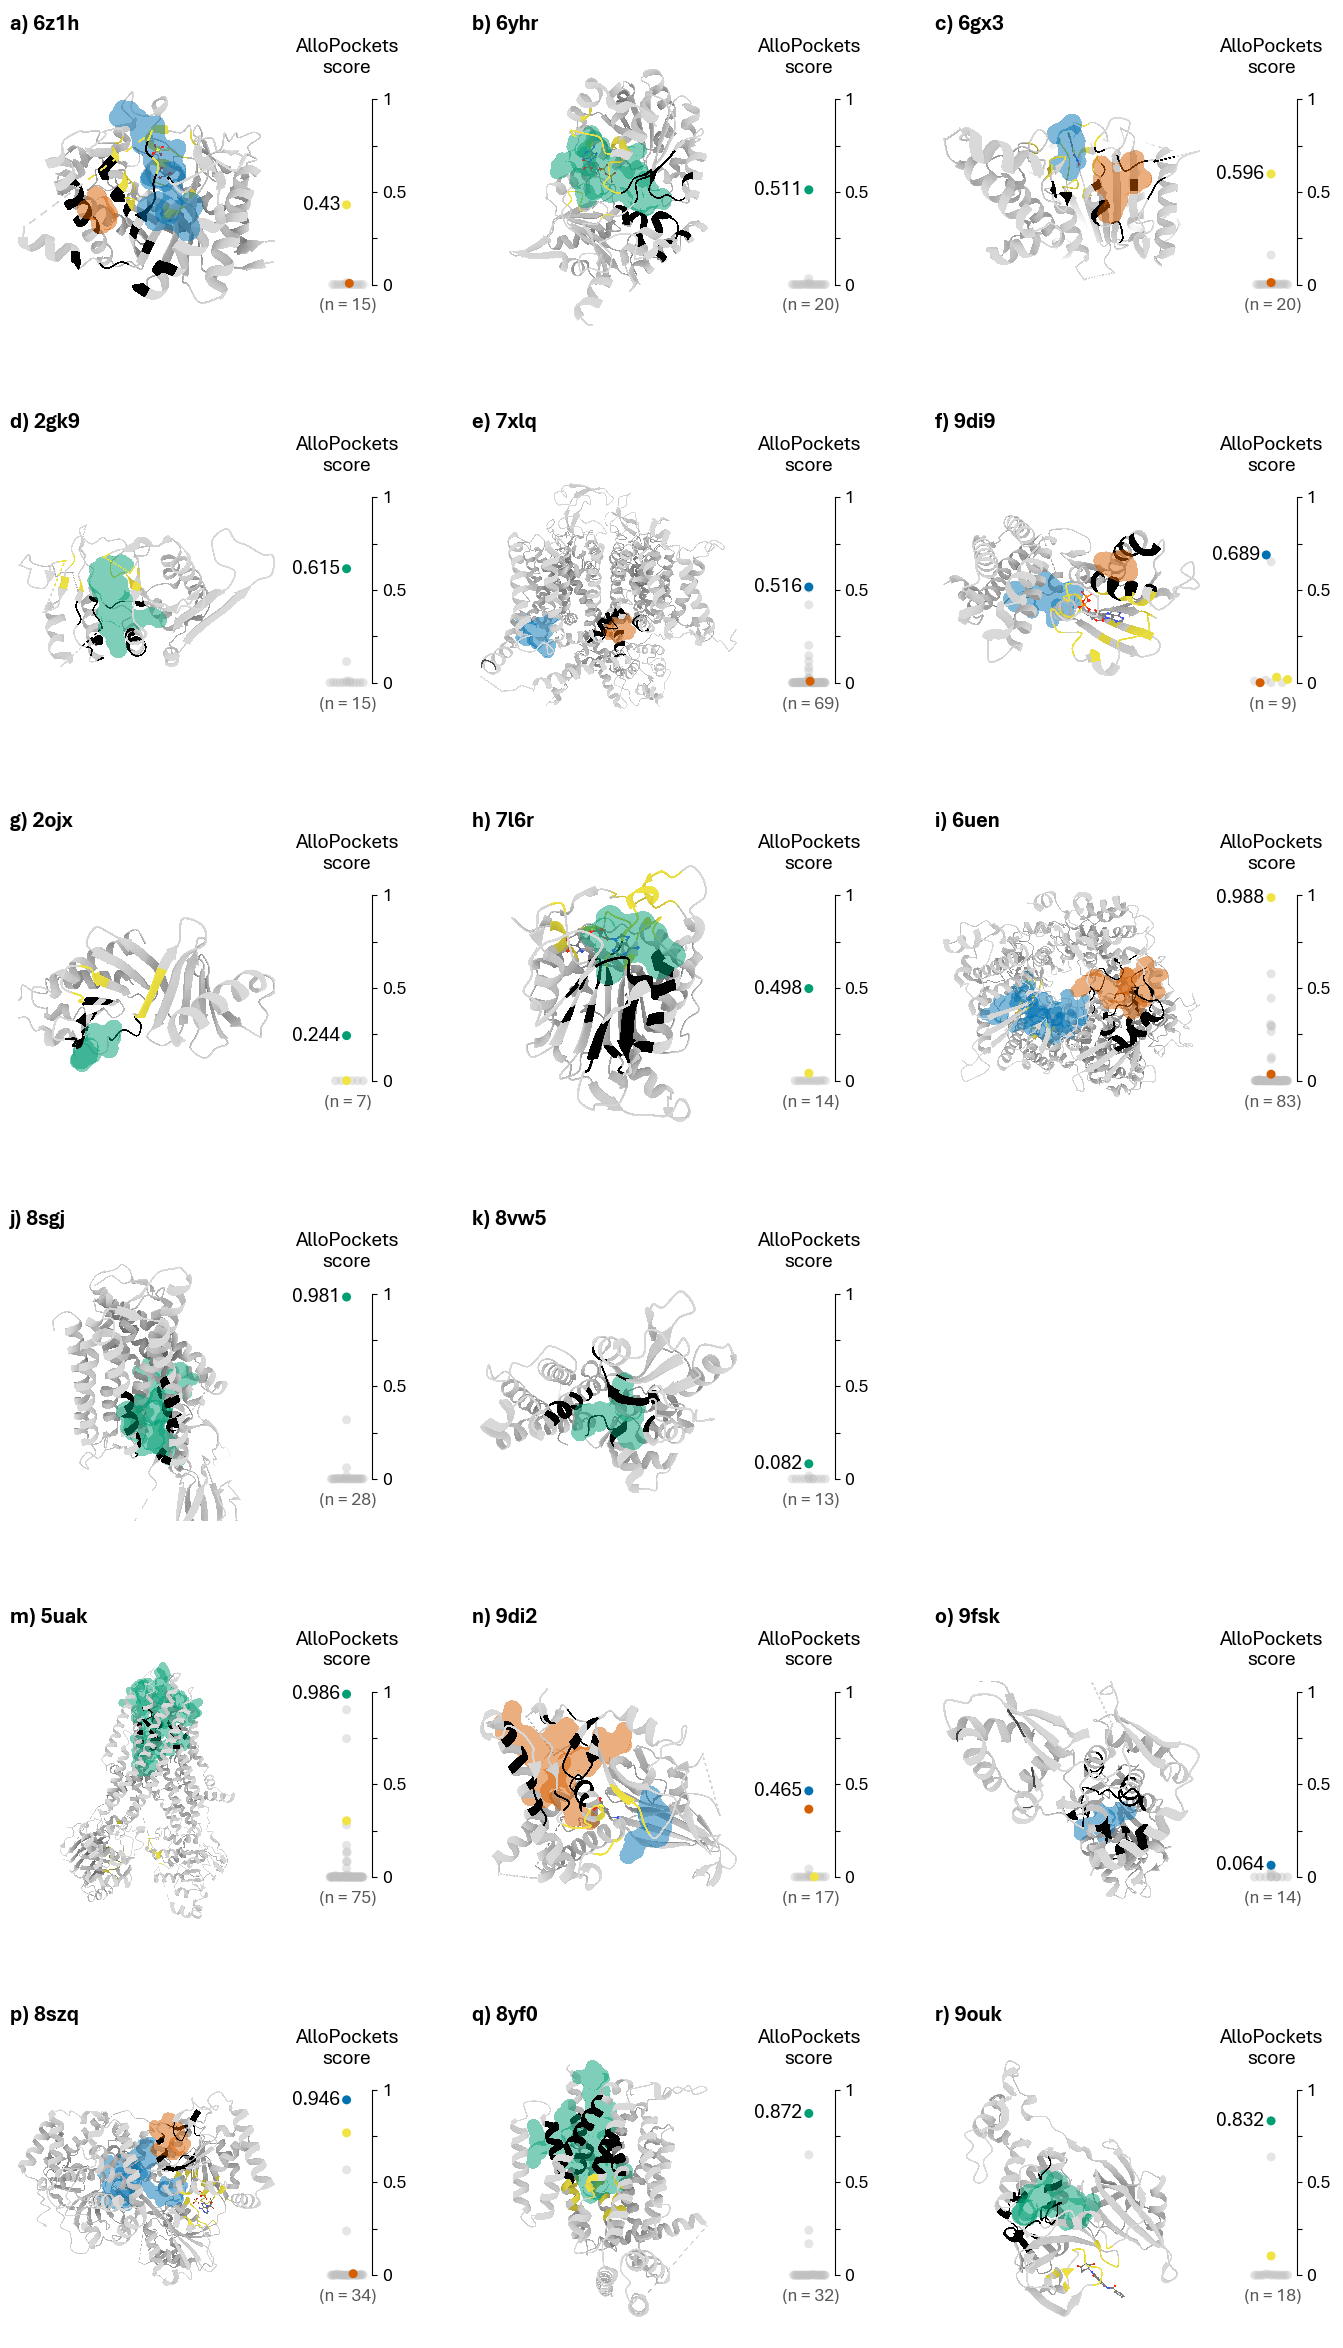

Saved multi-panel figure to images/multipanel_figure.svg


In [184]:
from pathlib import Path
from string import ascii_lowercase

import matplotlib.image as mpimg
from matplotlib import rcParams

names = {
    '6z1h': '6z1h',
    '6yhr': '6yhr',
    '6gx3': '6gx3',
    '2gk9': '2gk9',
    '7xlq': '7xlq',
    '9di9': '9di9',
    '2ojx': '2ojx',
    '7l6r': '7l6r',
    '6uen': '6uen',
    '8sgj': '8sgj',
    '8vw5': '8vw5',
    '5uak': '5uak',
    '9di2': '9di2',
    '9fsk': '9fsk',
    '8szq': '8szq',
    '8yf0': '8yf0',
    '9ouk': '9ouk'
}
# Titles can use Matplotlib mathtext for italics, e.g. r"22mj | $\it{Protein\ Name}$"
# TODO: add explicit line breaks ("\n") for titles that should span two lines.

figure_config = {
    "ncols": 3,
    "nrows": 6,
    "figsize": (14, 24),
    "font_scale": 1.15,
    "left": 0.04,
    "right": 0.985,
    "top": 0.99,
    "bottom": 0.02,
    "wspace": 0.16,
    "hspace": 0.18,
    "panel_hspace": 0.008,
    "panel_wspace": 0.02,
    "title_height_ratio": 0.11,
    "image_height_ratio": 0.89,
    "protein_width_ratio": 0.72,
    "scatter_width_ratio": 0.32,
    "protein_max_width": 0.94,
    "protein_max_height": 0.94,
    "panel_label_fontsize": 14,
    "panel_label_weight": "bold",
    "title_fontsize": 14,
    "header_fontweight": "bold",
    "label_x": 0.0,
    "title_x": 0.12,
    "title_y": 0.6,
    "panel_facecolor": "none",
    "figure_facecolor": "none",
    "scatter_config": {
        **scatter_config,
        "figsize": (2.2, 2.8),
        "point_size": 42,
        "tick_fontsize": 11.8,
        "label_fontsize": 12.8,
        "xlabel_fontsize": 11.8,
        "score_title_fontsize": 13.4,
    },
    "output_path": "images/multipanel_figure.svg",
}

font_scale = figure_config["font_scale"]
figure_config["panel_label_fontsize"] *= font_scale
figure_config["title_fontsize"] *= font_scale
for key in ["tick_fontsize", "label_fontsize", "xlabel_fontsize", "score_title_fontsize"]:
    figure_config["scatter_config"][key] *= font_scale

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"


def draw_centered_image(ax, image_path, max_width=0.94, max_height=0.94):
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing protein render for {image_path.stem}: {image_path}")

    img = mpimg.imread(image_path)
    height, width = img.shape[:2]
    aspect = width / height

    disp_width = max_width
    disp_height = disp_width / aspect
    if disp_height > max_height:
        disp_height = max_height
        disp_width = disp_height * aspect

    x0 = (1 - disp_width) / 2
    x1 = x0 + disp_width
    y0 = (1 - disp_height) / 2
    y1 = y0 + disp_height

    ax.imshow(
        img,
        extent=(x0, x1, y0, y1),
        aspect="auto",
        interpolation="none",
        resample=False,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_facecolor("none")
    ax.axis("off")


pdb_order = list(names)
# assert len(pdb_order) == figure_config["ncols"] * figure_config["nrows"]

fig = plt.figure(figsize=figure_config["figsize"], facecolor=figure_config["figure_facecolor"])
outer = fig.add_gridspec(
    figure_config["nrows"],
    figure_config["ncols"],
    left=figure_config["left"],
    right=figure_config["right"],
    top=figure_config["top"],
    bottom=figure_config["bottom"],
    wspace=figure_config["wspace"],
    hspace=figure_config["hspace"],
)

for panel_idx, pdb_id in enumerate(pdb_order):
    if panel_idx >= 11:
        panel_idx += 1
    row = panel_idx // figure_config["ncols"]
    col = panel_idx % figure_config["ncols"]
    header = f"{ascii_lowercase[panel_idx]}) {names[pdb_id]}"

    panel = outer[row, col].subgridspec(
        2,
        1,
        height_ratios=[figure_config["title_height_ratio"], figure_config["image_height_ratio"]],
        hspace=figure_config["panel_hspace"],
    )

    title_ax = fig.add_subplot(panel[0])
    title_ax.set_facecolor(figure_config["panel_facecolor"])
    title_ax.axis("off")
    title_ax.text(
        figure_config["label_x"],
        figure_config["title_y"],
        header,
        fontsize=figure_config["title_fontsize"],
        fontweight=figure_config["header_fontweight"],
        ha="left",
        va="center",
    )

    content = panel[1].subgridspec(
        1,
        2,
        width_ratios=[figure_config["protein_width_ratio"], figure_config["scatter_width_ratio"]],
        wspace=figure_config["panel_wspace"],
    )

    protein_ax = fig.add_subplot(content[0])
    protein_ax.set_facecolor(figure_config["panel_facecolor"])
    draw_centered_image(
        protein_ax,
        Path("images") / f"{pdb_id}.png",
        max_width=figure_config["protein_max_width"],
        max_height=figure_config["protein_max_height"],
    )

    scatter_host_ax = fig.add_subplot(content[1])
    scatter_host_ax.set_facecolor(figure_config["panel_facecolor"])
    scatter_host_ax.axis("off")
    scatter_ax = scatter_host_ax.inset_axes([0.15, 0.21, 0.68, 0.62])
    scatter_ax.set_facecolor("none")
    plot_scatter_panel(
        pdb_id,
        df,
        ax=scatter_ax,
        config=figure_config["scatter_config"],
        show_xlabel=True,
        show_score_title=True,
    )

fig.savefig(figure_config["output_path"], transparent=True)
fig.savefig(
    Path(figure_config["output_path"]).with_suffix(".pdf"),#"images/multipanel_figure.pdf",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True,
)
plt.show()
print(f"Saved multi-panel figure to {figure_config['output_path']}")


## Ignorelight tests